In [ ]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
# If you're running the notebook from a subfolder, walk up until we find "data"
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from src.copula.copula_calculation import construct_ecdf_lin
from src.copula.pair_selection import PairsSelector
from src.copula import fit_copula_to_empirical_data
from src.copula.archimedean import (Gumbel, Clayton, Frank, Joe, N13, N14)
from src.copula.elliptical import (StudentCopula, GaussianCopula)
from src.copula.elliptical import fit_nu_for_t_copula
import  src.copula.copula_calculation as ccalc
from src.visual.main import plot_equity

from src.trading.copula_basic_rules import BasicCopulaTradingRule
from src.trading.copula_mpi import MPICopulaTradingRule

# Copula Utilities

## Empirical Cumluative  Distribtuion Function - ECDF

In [22]:

prices = pd.read_csv('../data/sample-data/prices_10y_SP500.csv', index_col=0, parse_dates=True).fillna(method='ffill')
prices = prices[['AAPL', 'MSFT']][:365]
prices
# prices = pd.read_csv('FILE_PATH' + 'AAPL_MSFT_prices.csv').set_index('Date').dropna()

# Training and testing split
training_len = int(len(prices) * 0.7)
prices_train = prices.iloc[:training_len, :]
prices_test = prices.iloc[training_len:, :]

# Construct ECDF on training set
ecdf_aapl = construct_ecdf_lin(prices_train['AAPL'])

# Apply the trained ECDF on testing set
quantile_aapl = prices_test['AAPL'].map(ecdf_aapl)

/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_77977/3851903940.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prices = pd.read_csv('../data/sample-data/prices_10y_SP500.csv', index_col=0, parse_dates=True).fillna(method='ffill')


> Because prices are not stationary the quantile plot looks incorrect

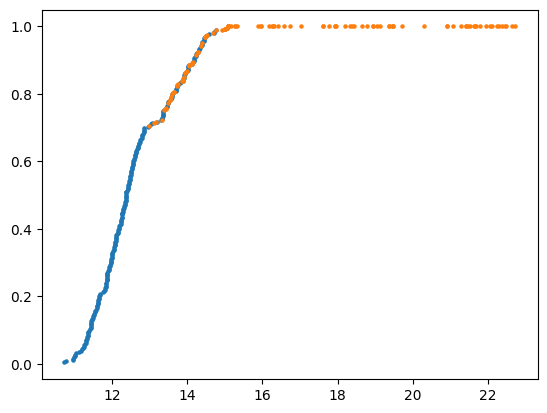

In [49]:
plt.scatter(prices_train['AAPL'], prices_train['AAPL'].map(ecdf_aapl), s = 5)

plt.scatter(prices_test['AAPL'], quantile_aapl, s = 5)

## Pair Selection

In [53]:
# Training and testing split
stocks_universe = pd.read_csv('../data/sample-data/prices_10y_SP500.csv', index_col=0, parse_dates=True).fillna(method='ffill')

training_len = int(len(stocks_universe) * 0.7)
prices_train = stocks_universe.iloc[:training_len, :]
prices_test = stocks_universe.iloc[training_len:, :]

# Rank pairs from training set
PS = PairsSelector()
scores_tau = PS.rank_pairs(prices_train, method='kendall tau', keep_num_pairs=1000)
scores_rho = PS.rank_pairs(prices_train, method='spearman rho', keep_num_pairs=1000)
scores_dis = PS.rank_pairs(prices_train, method='euc distance', keep_num_pairs=1000)

/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_77977/1342075651.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  stocks_universe = pd.read_csv('../data/sample-data/prices_10y_SP500.csv', index_col=0, parse_dates=True).fillna(method='ffill')
/Users/oriolripalta/Desktop/Projects/QuantTrading/src/copula/pair_selection.py:98: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  stocks_universe = stocks_universe.fillna(method='ffill', inplace=False)
/Users/oriolripalta/Desktop/Projects/QuantTrading/src/copula/pair_selection.py:98: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  stocks_universe = stocks_universe.fillna(method='ffill', inplace=False)
/Users/oriolripalta/Desktop/Projects/QuantTrading/src/copula/pair_

>`NOTE`: there is likely an error in the code

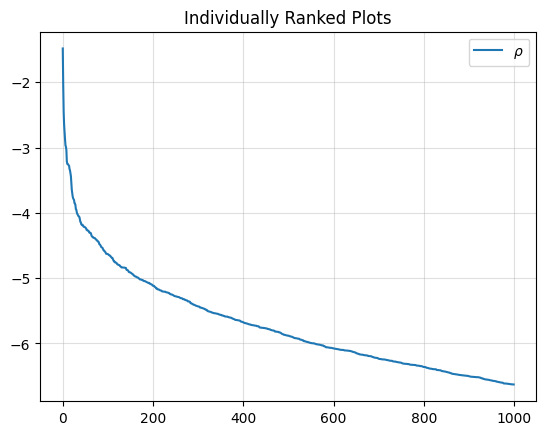

In [62]:

tau_sorted = scores_tau.sort_values(ascending=False).reset_index(drop=True)
rho_sorted = scores_rho.sort_values(ascending=False).reset_index(drop=True)
rho_sorted = scores_dis.sort_values(ascending=False).reset_index(drop=True)


# plt.plot(tau_sorted.index, tau_sorted.values, label=r'$\tau$')
plt.plot(rho_sorted.index, rho_sorted.values, label=r'$\rho$')

plt.title("Individually Ranked Plots")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

## Additional: Revisit MPI

/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_77977/3108910775.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prices = pd.read_csv('../data/sample-data/prices_10y_SP500.csv', index_col=0, parse_dates=True).fillna(method='ffill')[:1200]


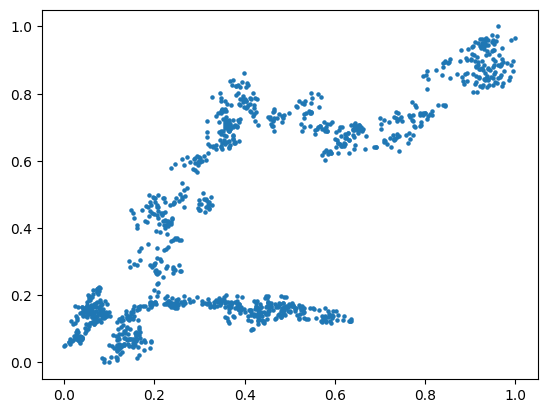

In [75]:
prices = pd.read_csv('../data/sample-data/prices_10y_SP500.csv', index_col=0, parse_dates=True).fillna(method='ffill')[:1200]
sp500_rts = prices.pct_change().dropna()

# plt.scatter(sp500_rts['AAPL'], sp500_rts['MSFT'], s = 5)
prices_norm = (prices - prices.min()) / (prices.max() - prices.min())

x_price = prices_norm["AAPL"]
y_price = prices_norm["BA"]

plt.scatter(x_price, y_price, s = 5)

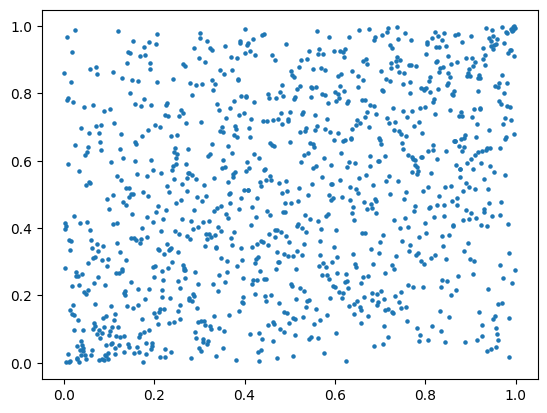

In [78]:
u = sp500_rts.rank(method="average") / (len(sp500_rts) + 1)

x_ret = u["AAPL"]
y_ret = u["BA"]

plt.scatter(x_ret, y_ret, s = 5)

# Variations in MPI approach

In [26]:
prices = pd.read_csv('../data/sample-data/BKD_ESC_2008_2009_June.csv', parse_dates=True, index_col=0)
# data = pd.read_csv('../data/sample-data/BKD_ESC_2009_2011.csv', index_col=0)

# train_len = int(len(prices) * 0.7)
train_len = 252

returns = prices.pct_change().dropna()

prices_train = prices.iloc[: train_len, :]
prices_test = prices.iloc[train_len :, :]

CSMPI = MPICopulaTradingRule(opening_triggers = (-0.6, 0.6), stop_loss_positions = (-2, 2))
returns_train = CSMPI.to_returns(prices_train)
returns_test = CSMPI.to_returns(prices_test)
# returns_train = returns.iloc[: train_len, :]
# returns_test = returns.iloc[train_len :, :]

In [27]:
copulas = [Gumbel, Clayton, Frank, Joe, N13, N14, GaussianCopula, StudentCopula]

# # Fit different copulas, store the results in dictionaries
# fit_result_gumbel, copula_gumbel, cdf_x_gumbel, cdf_y_gumbel =\
#     ccalc.fit_copula_to_empirical_data(x = bkd_prices, y = esc_prices, copula=Gumbel)

# fit_result_frank, copula_frank, cdf_x_frank, cdf_y_frank =\
#     ccalc.fit_copula_to_empirical_data(x = bkd_prices, y = esc_prices, copula=Frank)

# fit_result_clayton, copula_clayton, cdf_x_clayton, cdf_y_clayton =\
#     ccalc.fit_copula_to_empirical_data(x = bkd_prices, y = esc_prices, copula=Clayton)

# fit_result_joe, copula_joe, cdf_x_joe, cdf_x_joe=\
#     ccalc.fit_copula_to_empirical_data(x = bkd_prices, y = esc_prices, copula=Joe)

# fit_result_n14, copula_n14, cdf_x_n14, cdf_y_n14=\
#     ccalc.fit_copula_to_empirical_data(x = bkd_prices, y = esc_prices, copula=N14)

# fit_result_gauss, copula_gauss, cdf_x_gauss, cdf_y_gauss =\
#     ccalc.fit_copula_to_empirical_data(x = bkd_prices, y = esc_prices, copula=GaussianCopula)

# fit_result_t, copula_t, cdf_x_t, cdf_y_t=\
#     ccalc.fit_copula_to_empirical_data(x = bkd_prices, y = esc_prices, copula=StudentCopula)

copulas_data = {}

for cop in copulas:
    info_crit_logs, fit_copula, ecdf_x, ecdf_y = fit_copula_to_empirical_data(x = returns_train['BKD'], y = returns_train['ESC'], copula = cop)
    copulas_data[info_crit_logs['Copula Name']] = {
        "fitted": fit_copula,
        "cdf_x": ecdf_x,
        "cdf_y": ecdf_y,
    }

print(copulas_data)

{'Gumbel': {'fitted': <src.copula.archimedean.gumbel.Gumbel object at 0x149859490>, 'cdf_x': <numpy.vectorize object at 0x149875610>, 'cdf_y': <numpy.vectorize object at 0x1499e9610>}, 'Clayton': {'fitted': <src.copula.archimedean.clayton.Clayton object at 0x1498ea490>, 'cdf_x': <numpy.vectorize object at 0x149922ed0>, 'cdf_y': <numpy.vectorize object at 0x14861d590>}, 'Frank': {'fitted': <src.copula.archimedean.frank.Frank object at 0x149922a90>, 'cdf_x': <numpy.vectorize object at 0x1499d9510>, 'cdf_y': <numpy.vectorize object at 0x1498e1ad0>}, 'Joe': {'fitted': <src.copula.archimedean.joe.Joe object at 0x149935cd0>, 'cdf_x': <numpy.vectorize object at 0x149a0ad10>, 'cdf_y': <numpy.vectorize object at 0x149a0abd0>}, 'N13': {'fitted': <src.copula.archimedean.n13.N13 object at 0x149a0b190>, 'cdf_x': <numpy.vectorize object at 0x149a082d0>, 'cdf_y': <numpy.vectorize object at 0x149a0bf10>}, 'N14': {'fitted': <src.copula.archimedean.n14.N14 object at 0x149a08250>, 'cdf_x': <numpy.vectori

In [28]:
copulas_data.keys()

# copulas_data['Student'].get('fitted')

dict_keys(['Gumbel', 'Clayton', 'Frank', 'Joe', 'N13', 'N14', 'Gaussian', 'Student'])

In [30]:
# CSMPI = MPICopulaTradingRule(opening_triggers = (-0.2, 0.2), stop_loss_positions = (-2, 2))
CSMPI = MPICopulaTradingRule(opening_triggers = (-0.6, 0.6), stop_loss_positions = (-2, 2))

CSMPI.set_copula(copulas_data['Student'].get('fitted'))

CSMPI.set_cdf(copulas_data['Student'].get('cdf_x'),
              copulas_data['Student'].get('cdf_y'))

In [31]:
positions, flags = CSMPI.get_positions_and_flags(returns = returns_test,
                                                 enable_reset_flag=True)
# positions, flags = CSMPI.get_positions_and_flags(returns = returns_test, open_rule='and', exit_rule='or')
positions = positions.shift(1)
positions[0] = 0


/Users/oriolripalta/Desktop/Projects/QuantTrading/src/trading/copula_mpi.py:253: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  positions[0] = init_pos
/Users/oriolripalta/Desktop/Projects/QuantTrading/src/trading/copula_mpi.py:266: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4225483333506007' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  flags.iloc[i, :] = cur_flag
/Users/oriolripalta/Desktop/Projects/QuantTrading/src/trading/copula_mpi.py:266: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.04919699089107471' has dtype incompatible with int64, please explicitly cast to a compatible dty

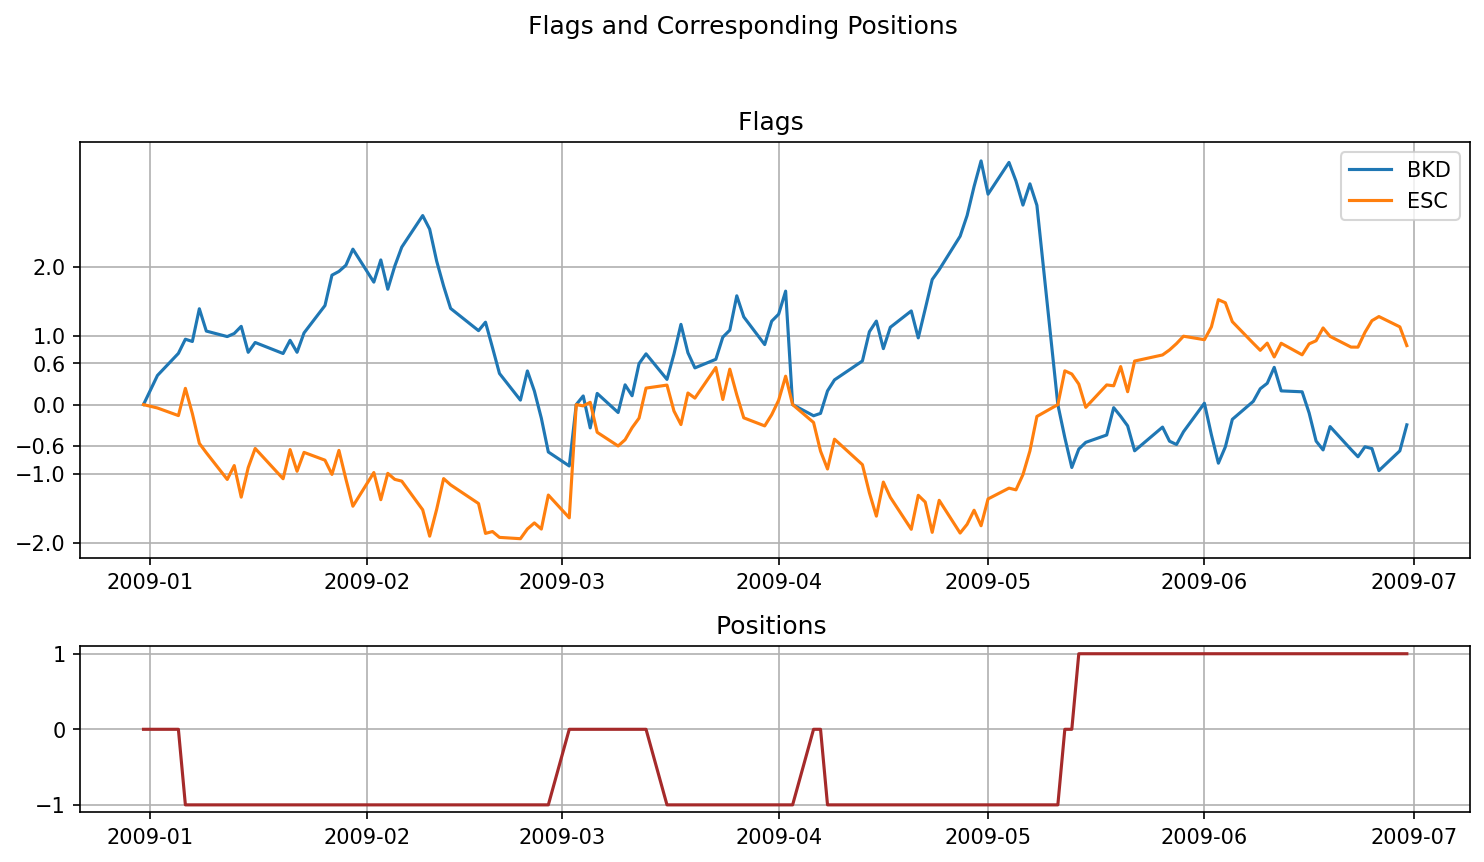

In [32]:
CSMPI.plot_positions_n_flags(positions, flags);

/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_20388/2443494328.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(prices_test['BKD'] / prices_test['BKD'][0], label = 'BKD')
/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_20388/2443494328.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(prices_test['ESC'] / prices_test['ESC'][0], label = 'ESC')


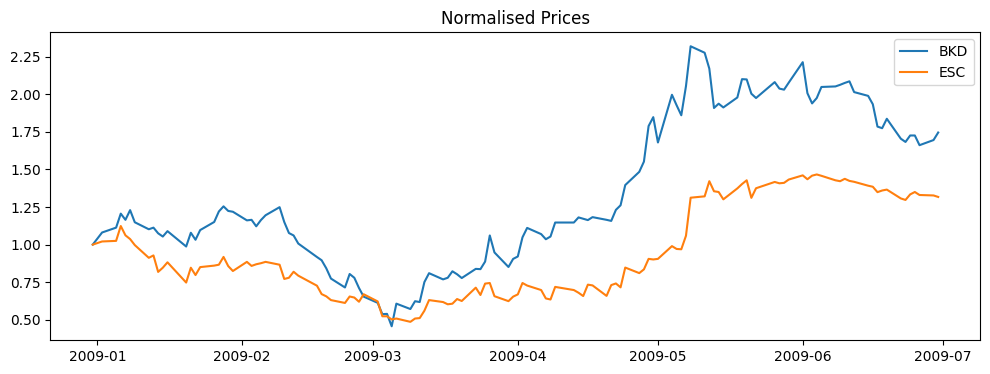

In [14]:
import matplotlib.dates as mdates

plt.figure(figsize = (12, 4))
plt.plot(prices_test['BKD'] / prices_test['BKD'][0], label = 'BKD')
plt.plot(prices_test['ESC'] / prices_test['ESC'][0], label = 'ESC')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.title('Normalised Prices')
plt.legend()
plt.show()

/Users/oriolripalta/Desktop/Projects/QuantTrading/src/trading/copula_mpi.py:182: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.08051529790660225' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  units_df.iloc[i, 0] = - short_units
/Users/oriolripalta/Desktop/Projects/QuantTrading/src/trading/copula_mpi.py:183: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.048638132295719845' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  units_df.iloc[i, 1] = long_units


<Axes: title={'center': 'Equity Curve'}>

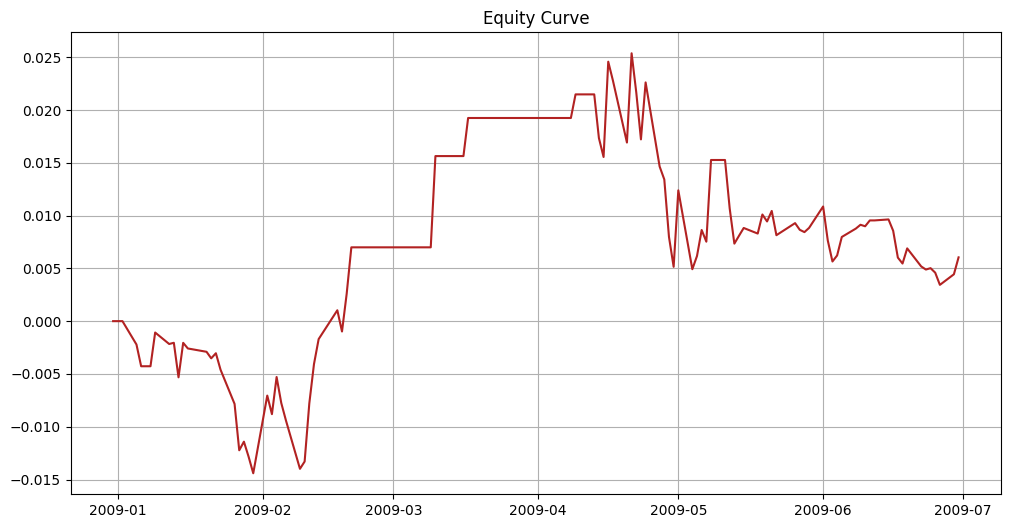

In [15]:
units = CSMPI.positions_to_units_dollar_neutral(prices_df = prices_test, positions = positions)

portfolio = returns_test['BKD'] * units['BKD'] + returns_test['ESC'] * units['ESC']

equity = portfolio.cumsum()

plot_equity(equity)

In [96]:
returns_test

,BKD,ESC
Dates,,
1/20/2009,-0.093750,-0.152542
1/21/2009,0.092559,0.132000
1/22/2009,-0.043189,-0.057715
1/23/2009,0.062500,0.066250
1/26/2009,0.049020,0.011723
...,...,...
6/24/2009,0.025559,0.028440
6/25/2009,0.000000,0.011958
6/26/2009,-0.037383,-0.014771



    - vine [x]
        - explain the stratgegy better [ ]
        - replicate the sp perfromance from video [ ]
        - redo the bollinger band imange on test data [ ]
    - pair selection [x]
- Get IBEX data after this [ ]

review copula notes, and go over them again. Then organise report adn push
Organise repo
> Note for myself. Review MPI and work towards its implementaiton

> Users can create and fit copulas to data and use them directly. Also, the fitted copulas can be used in trading
strategies such as :code:`BasicCopulaTradingRule` and :code:`MispricingIndexCopulaTradingRule` class described in the
:ref:`Copula Trading Strategies <trading-basic_copula>` section of the documentation.

# Next steps 
eitehr of them
- focus on implementing directly
- understand how is copula data fitted